In [1]:
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
#All from other notebook
#initialization
import matplotlib.pyplot as plt
import numpy as np
import math

# importing Qiskit
from qiskit_aer import Aer
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister, transpile

# import basic plot tools
from qiskit.visualization import plot_histogram, plot_bloch_multivector

backend = Aer.get_backend('qasm_simulator')

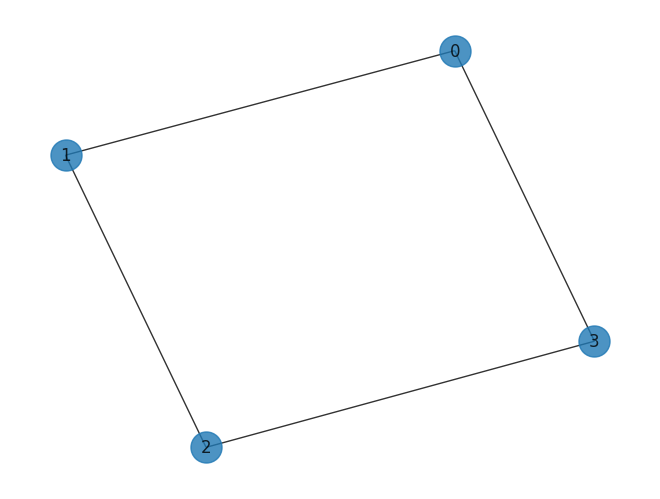

In [3]:
import networkx as nx

G = nx.Graph()
G.add_nodes_from([0, 1, 2, 3])
G.add_edges_from([(0, 1), (1, 2), (2, 3), (3,0)])
nx.draw(G, with_labels=True, alpha=0.8, node_size=500)

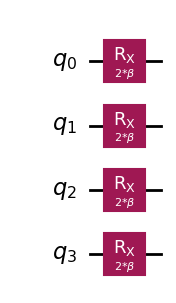

In [4]:
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit.circuit import Parameter

# Adjacency is essentially a matrix which tells you which nodes are
# connected. This matrix is given as a sparse matrix, so we need to
# convert it to a dense matrix
adjacency = nx.adjacency_matrix(G).todense()

nqubits = 4

beta = Parameter("$\\beta$")
qc_mix = QuantumCircuit(nqubits)
for i in range(0, nqubits):
    qc_mix.rx(2 * beta, i)
    
qc_mix.draw('mpl')

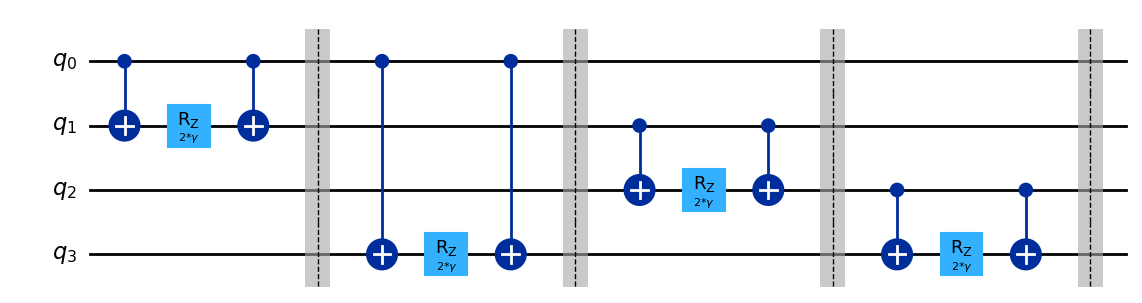

In [5]:
gamma = Parameter("$\\gamma$")
qc_p = QuantumCircuit(nqubits)
for pair in list(G.edges()):  # pairs of nodes
    qc_p.rzz(2 * gamma, pair[0], pair[1])
    qc_p.barrier()
    
qc_p.decompose().draw('mpl')


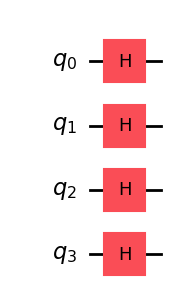

In [6]:
qc_0 = QuantumCircuit(nqubits)
for i in range(0, nqubits):
    qc_0.h(i)
    
qc_0.draw('mpl')

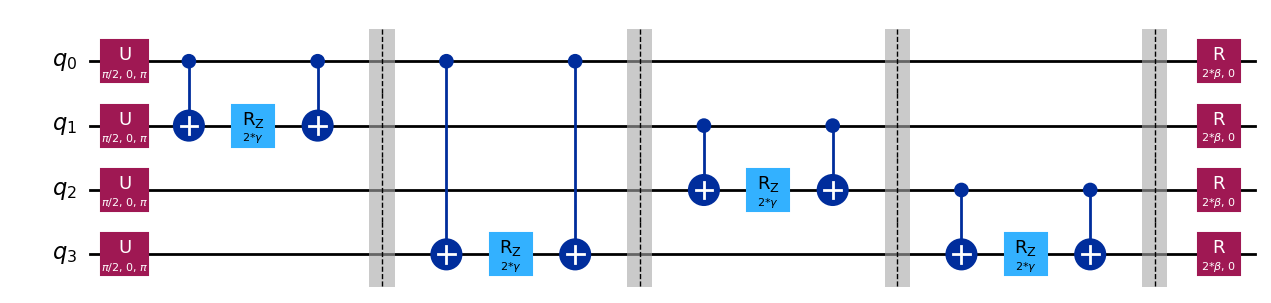

In [7]:
qc_qaoa = QuantumCircuit(nqubits)

qc_qaoa.append(qc_0, [i for i in range(0, nqubits)])
qc_qaoa.append(qc_p, [i for i in range(0, nqubits)])
qc_qaoa.append(qc_mix, [i for i in range(0, nqubits)])

qc_qaoa.decompose().decompose().draw('mpl')

In [ ]:
def maxcut_obj(x, G):
    """
    Given a bitstring as a solution, this function returns
    the number of edges shared between the two partitions
    of the graph.
    
    Args:
        x: str
           solution bitstring
           
        G: networkx graph
        
    Returns:
        obj: float
             Objective
    """
    obj = 0
    for i, j in G.edges():
        if x[i] != x[j]:
            obj -= 1
            
    return obj


def compute_expectation(counts, G):
    
    """
    Computes expectation value based on measurement results
    
    Args:
        counts: dict
                key as bitstring, val as count
           
        G: networkx graph
        
    Returns:
        avg: float
             expectation value
    """
    
    avg = 0
    sum_count = 0
    for bitstring, count in counts.items():
        
        obj = maxcut_obj(bitstring[::-1], G)
        avg += obj * count
        sum_count += count
        
    return avg/sum_count


# We will also bring the different circuit components that
# build the qaoa circuit under a single function
def create_qaoa_circ(G, theta):
    
    """
    Creates a parametrized qaoa circuit
    
    Args:  
        G: networkx graph
        theta: list
               unitary parameters
                     
    Returns:
        qc: qiskit circuit
    """
    
    nqubits = len(G.nodes())
    p = len(theta)//2  # number of alternating unitaries
    #print('theta: ', theta)
    #print('p: ', p)
    qc = QuantumCircuit(nqubits)
    
    beta = theta[:p]
    gamma = theta[p:]
    #extra start
    print('beta: ', beta)
    print('gamma: ', gamma)
    ##extra done
    
    # initial_state
    for i in range(0, nqubits):
        qc.h(i)
    
    for irep in range(0, p):
        
        # problem unitary
        for pair in list(G.edges()):
            qc.rzz(2 * gamma[irep], pair[0], pair[1])

        # mixer unitary
        for i in range(0, nqubits):
            qc.rx(2 * beta[irep], i)
            
    qc.measure_all()
        
    return qc

# 2.1 Add a graph in the optimisation function which shows the evolution of the beta and gamma parameter in the algorithm.
# History lists to track parameter evolution across iterations
beta_history = []
gamma_history = []

def execute_circ(theta):
    """Evaluate the QAOA circuit and record beta/gamma at each call."""
    p = len(theta) // 2
    beta_history.append(list(theta[:p]))
    gamma_history.append(list(theta[p:]))
    
    qc = create_qaoa_circ(G, theta)
    counts = backend.run(qc, seed_simulator=10,
                         nshots=512).result().get_counts()
    
    return compute_expectation(counts, G)


def get_expectation(G, shots=512):
    backend.shots = shots
    beta_history.clear()
    gamma_history.clear()
    return execute_circ


def plot_parameter_evolution():
    iterations = list(range(1, len(beta_history) + 1))
    p = len(beta_history[0])
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle('Evolution of QAOA Parameters During Optimisation', fontsize=14)
    
    ax_beta = axes[0]
    for layer in range(p):
        vals = [beta_history[i][layer] for i in range(len(beta_history))]
        ax_beta.plot(iterations, vals, marker='o', label=fr'$\beta_{{{layer+1}}}$')
    ax_beta.set_xlabel('Iteration')
    ax_beta.set_ylabel(r'$\beta$')
    ax_beta.set_title(r'Mixer parameter $\beta$')
    ax_beta.legend()
    ax_beta.grid(True, alpha=0.3)
    
    ax_gamma = axes[1]
    for layer in range(p):
        vals = [gamma_history[i][layer] for i in range(len(gamma_history))]
        ax_gamma.plot(iterations, vals, marker='s', label=fr'$\gamma_{{{layer+1}}}$')
    ax_gamma.set_xlabel('Iteration')
    ax_gamma.set_ylabel(r'$\gamma$')
    ax_gamma.set_title(r'Problem parameter $\gamma$')
    ax_gamma.legend()
    ax_gamma.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    print(f'Optimisation converged in {len(beta_history)} iterations.')

beta:  [1.]
gamma:  [1.]
beta:  [2.]
gamma:  [1.]
beta:  [2.]
gamma:  [2.]
beta:  [2.60303802]
gamma:  [0.20228755]
beta:  [2.37777989]
gamma:  [1.32753986]
beta:  [1.91811504]
gamma:  [1.09444497]
beta:  [1.6687284]
gamma:  [1.07694344]
beta:  [1.95589302]
gamma:  [1.12719896]
beta:  [1.94706819]
gamma:  [1.22680881]
beta:  [2.00569795]
gamma:  [1.13161138]
beta:  [1.94992819]
gamma:  [1.15147695]
beta:  [1.9390115]
gamma:  [1.17396752]
beta:  [1.94543007]
gamma:  [1.14929361]
beta:  [1.95839911]
gamma:  [1.14616249]
beta:  [1.96723534]
gamma:  [1.15084449]
beta:  [1.95821652]
gamma:  [1.14116583]
beta:  [1.95964828]
gamma:  [1.14611684]
beta:  [1.95849041]
gamma:  [1.14866082]
beta:  [1.95841737]
gamma:  [1.14666216]
beta:  [1.95845389]
gamma:  [1.14766149]
beta:  [1.95802183]
gamma:  [1.14635631]
beta:  [1.95849383]
gamma:  [1.14656327]
beta:  [1.95837782]
gamma:  [1.14663157]
 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  stat

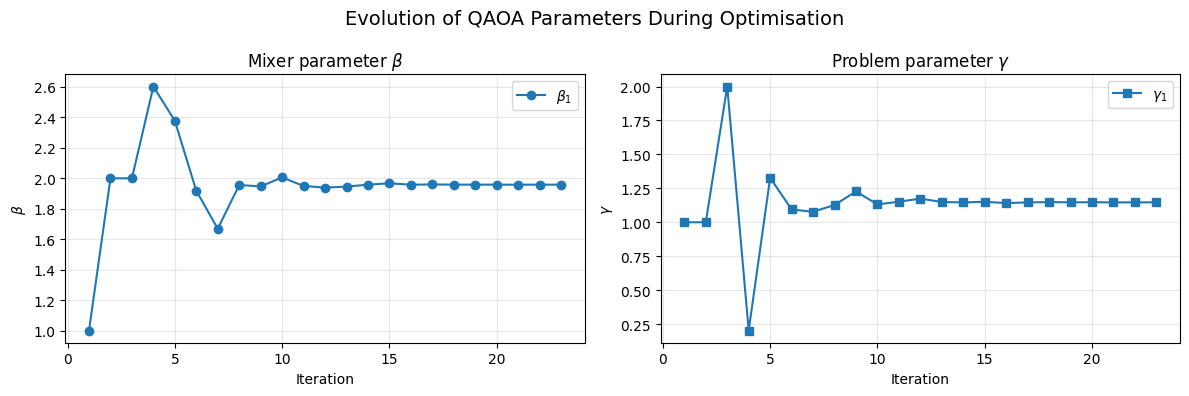

Optimisation converged in 23 iterations.


In [9]:
from scipy.optimize import minimize

expectation = get_expectation(G)

res = minimize(expectation,
               [1.0, 1.0],
               method='COBYLA')

print(res)
plot_parameter_evolution()

beta:  [1.95841737]
gamma:  [1.14666216]


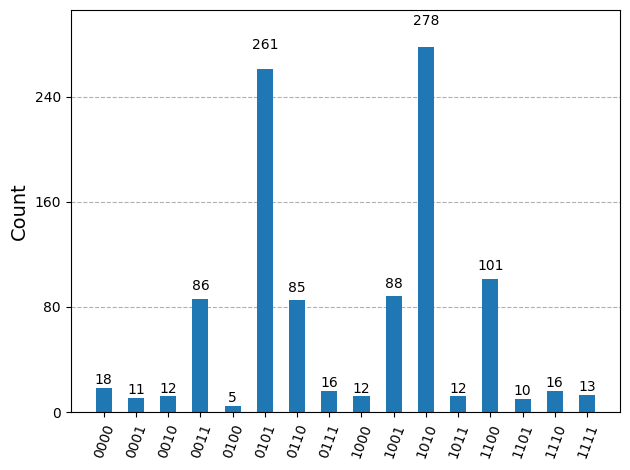

In [10]:
from qiskit.visualization import plot_histogram

backend = Aer.get_backend('aer_simulator')
backend.shots = 512

qc_res = create_qaoa_circ(G, res.x)

counts = backend.run(qc_res, seed_simulator=10).result().get_counts()

plot_histogram(counts)